## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

PALETTE = {
    'anxiety':    '#4C72B0',
    'stress':     '#DD8452',
    'depression': '#55A868',
    'risk':       ['#2ecc71', '#f39c12', '#e74c3c'],   # Low / Moderate / High
}

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Load Data

In [2]:
df_raw = pd.read_csv('../dataset/Raw Data.csv')
print(f'Shape: {df_raw.shape}  ({df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns)')
df_raw.head(3)

Shape: (1977, 39)  (1,977 rows × 39 columns)


,1. Age,2. Gender,3. University,4. Department,5. Academic Year,6. Current CGPA,7. Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?",...,"2. In a semester, how often have you been feeling down, depressed or hopeless?","3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much?","4. In a semester, how often have you been feeling tired or having little energy?","5. In a semester, how often have you had poor appetite or overeating?","6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down?","7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television?","8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless?","9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself?",Depression Value,Depression Label
0,18-22,Female,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Fourth Year or Equivalent,2.50 - 2.99,No,1,1,1,...,2,1,1,2,1,1,1,1,11,Moderate Depression
1,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.80 - 4.00,No,2,2,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
2,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.00 - 3.39,No,2,1,1,...,0,2,3,2,2,2,2,1,16,Moderately Severe Depression


## 3. Column Renaming - Readable Names

In [3]:
# ── Rename columns for ease of use ─────────────────────────────────────────
rename_map = {
    '1. Age':                      'Age',
    '2. Gender':                   'Gender',
    '3. University':               'University',
    '4. Department':               'Department',
    '5. Academic Year':            'Academic_Year',
    '6. Current CGPA':             'CGPA',
    '7. Did you receive a waiver or scholarship at your university?': 'Scholarship',
    # Anxiety items
    '1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? ': 'A1_Nervous',
    '2. In a semester, how often have you been unable to stop worrying about your academic affairs? ': 'A2_Worrying',
    '3. In a semester, how often have you had trouble relaxing due to academic pressure? ': 'A3_Relaxing',
    '4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?': 'A4_Irritated',
    '5. In a semester, how often have you worried too much about academic affairs? ': 'A5_TooMuchWorry',
    '6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?': 'A6_Restless',
    '7. In a semester, how often have you felt afraid, as if something awful might happen?': 'A7_Afraid',
    'Anxiety Value':  'Anxiety_Score',
    'Anxiety Label':  'Anxiety_Label',
    # Stress items
    '1. In a semester, how often have you felt upset due to something that happened in your academic affairs? ': 'S1_Upset',
    '2. In a semester, how often you felt as if you were unable to control important things in your academic affairs?': 'S2_Uncontrolled',
    '3. In a semester, how often you felt nervous and stressed because of academic pressure? ': 'S3_NervousStressed',
    '4. In a semester, how often you felt as if you could not cope with all the mandatory academic activities? (e.g, assignments, quiz, exams) ': 'S4_CannotCope',
    '5. In a semester, how often you felt confident about your ability to handle your academic / university problems?': 'S5_Confident',
    '6. In a semester, how often you felt as if things in your academic life is going on your way? ': 'S6_ThingsGoingWell',
    '7. In a semester, how often are you able to control irritations in your academic / university affairs? ': 'S7_ControlIrritations',
    '8. In a semester, how often you felt as if your academic performance was on top?': 'S8_PerformanceOnTop',
    '9. In a semester, how often you got angered due to bad performance or low grades that is beyond your control? ': 'S9_Angered',
    '10. In a semester, how often you felt as if academic difficulties are piling up so high that you could not overcome them? ': 'S10_PilingUp',
    'Stress Value':   'Stress_Score',
    'Stress Label':   'Stress_Label',
    # Depression items
    '1. In a semester, how often have you had little interest or pleasure in doing things?': 'D1_LittleInterest',
    '2. In a semester, how often have you been feeling down, depressed or hopeless?': 'D2_Hopeless',
    '3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much? ': 'D3_SleepTrouble',
    '4. In a semester, how often have you been feeling tired or having little energy? ': 'D4_Tired',
    '5. In a semester, how often have you had poor appetite or overeating? ': 'D5_Appetite',
    '6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down? ': 'D6_Failure',
    '7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television? ': 'D7_Concentration',
    '8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you\'ve been moving a lot more than usual because you\'ve been restless? ': 'D8_Psychomotor',
    '9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself? ': 'D9_SuicidalThoughts',
    'Depression Value': 'Depression_Score',
    'Depression Label': 'Depression_Label',
}

df = df_raw.rename(columns=rename_map)
print('✅ Columns renamed. Shape:', df.shape)
df.columns.tolist()

✅ Columns renamed. Shape: (1977, 39)


['Age',
 'Gender',
 'University',
 'Department',
 'Academic_Year',
 'CGPA',
 'Scholarship',
 'A1_Nervous',
 'A2_Worrying',
 'A3_Relaxing',
 'A4_Irritated',
 'A5_TooMuchWorry',
 'A6_Restless',
 'A7_Afraid',
 'Anxiety_Score',
 'Anxiety_Label',
 'S1_Upset',
 'S2_Uncontrolled',
 'S3_NervousStressed',
 'S4_CannotCope',
 'S5_Confident',
 'S6_ThingsGoingWell',
 'S7_ControlIrritations',
 'S8_PerformanceOnTop',
 'S9_Angered',
 'S10_PilingUp',
 'Stress_Score',
 'Stress_Label',
 'D1_LittleInterest',
 'D2_Hopeless',
 'D3_SleepTrouble',
 'D4_Tired',
 'D5_Appetite',
 'D6_Failure',
 'D7_Concentration',
 'D8_Psychomotor',
 'D9_SuicidalThoughts',
 'Depression_Score',
 'Depression_Label']

## 4. Dataset Overview

In [4]:
print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Total records   : {len(df):,}')
print(f'Total features  : {df.shape[1]}')
print(f'\nMissing Values  :')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '  None - Dataset is complete ✅')
print(f'\nDuplicate rows  : {df.duplicated().sum()}')

DATASET OVERVIEW
Total records   : 1,977
Total features  : 39

Missing Values  :
  None - Dataset is complete ✅

Duplicate rows  : 3


In [5]:
df.dtypes

Age                      object
Gender                   object
University               object
Department               object
Academic_Year            object
CGPA                     object
Scholarship              object
A1_Nervous                int64
A2_Worrying               int64
A3_Relaxing               int64
A4_Irritated              int64
A5_TooMuchWorry           int64
A6_Restless               int64
A7_Afraid                 int64
Anxiety_Score             int64
Anxiety_Label            object
S1_Upset                  int64
S2_Uncontrolled           int64
S3_NervousStressed        int64
S4_CannotCope             int64
S5_Confident              int64
S6_ThingsGoingWell        int64
S7_ControlIrritations     int64
S8_PerformanceOnTop       int64
S9_Angered                int64
S10_PilingUp              int64
Stress_Score              int64
Stress_Label             object
D1_LittleInterest         int64
D2_Hopeless               int64
D3_SleepTrouble           int64
D4_Tired

In [6]:
# Number of unique values per column
print('=' * 60)
print('UNIQUE VALUES PER COLUMN')
print('=' * 60)
unique_counts = df.nunique()
for col, count in unique_counts.items():
    print(f'{col:<25}: {count:>5} unique values')

UNIQUE VALUES PER COLUMN
Age                      :     5 unique values
Gender                   :     3 unique values
University               :    15 unique values
Department               :    12 unique values
Academic_Year            :     5 unique values
CGPA                     :     6 unique values
Scholarship              :     2 unique values
A1_Nervous               :     4 unique values
A2_Worrying              :     4 unique values
A3_Relaxing              :     4 unique values
A4_Irritated             :     4 unique values
A5_TooMuchWorry          :     4 unique values
A6_Restless              :     4 unique values
A7_Afraid                :     4 unique values
Anxiety_Score            :    22 unique values
Anxiety_Label            :     4 unique values
S1_Upset                 :     5 unique values
S2_Uncontrolled          :     5 unique values
S3_NervousStressed       :     5 unique values
S4_CannotCope            :     5 unique values
S5_Confident             :     5 un

In [7]:
# Numeric summary
numeric_cols = ['Anxiety_Score', 'Stress_Score', 'Depression_Score']
df[numeric_cols].describe().round(2)

,Anxiety_Score,Stress_Score,Depression_Score
count,1977.00,1977.00,1977.00
mean,12.29,22.96,14.37
std,5.50,6.75,6.66
min,0.00,0.00,0.00
25%,8.00,19.00,9.00
50%,13.00,22.00,14.00
75%,17.00,27.00,19.00
max,21.00,40.00,27.00


## 5. Target Variable - Depression Label Distribution

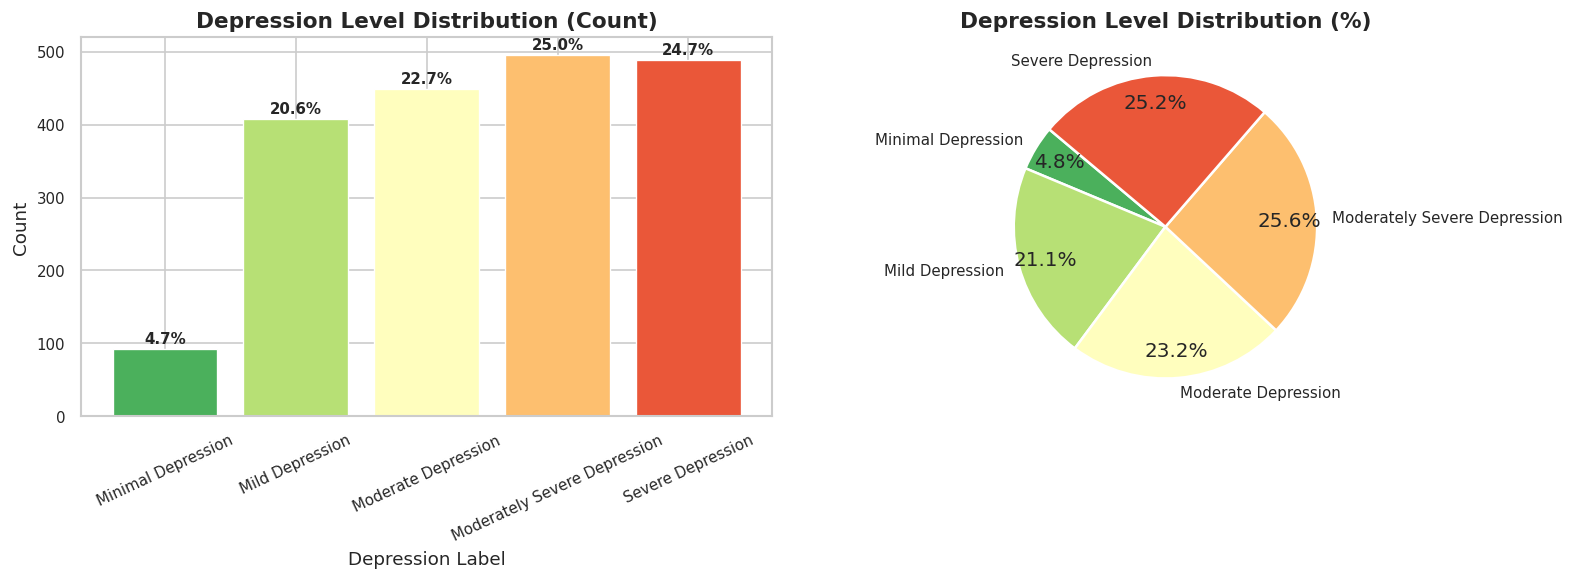

                              Count  Percentage
Depression_Label                               
Minimal Depression               93         4.7
Mild Depression                 408        20.6
Moderate Depression             449        22.7
Moderately Severe Depression    495        25.0
Severe Depression               488        24.7


In [8]:
label_order = [
    'Minimal Depression',
    'Mild Depression',
    'Moderate Depression',
    'Moderately Severe Depression',
    'Severe Depression',
]
existing_labels = [l for l in label_order if l in df['Depression_Label'].unique()]

counts = df['Depression_Label'].value_counts().reindex(existing_labels).dropna()
pct    = (counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('RdYlGn_r', len(counts))
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Depression Level Distribution (Count)', fontweight='bold')
axes[0].set_xlabel('Depression Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=25)
for i, (c, p) in enumerate(zip(counts, pct)):
    axes[0].text(i, c + 8, f'{p}%', ha='center', fontsize=9, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, pctdistance=0.82,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Depression Level Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.show()
print(pd.DataFrame({'Count': counts, 'Percentage': pct}))

## 6. Demographic Analysis

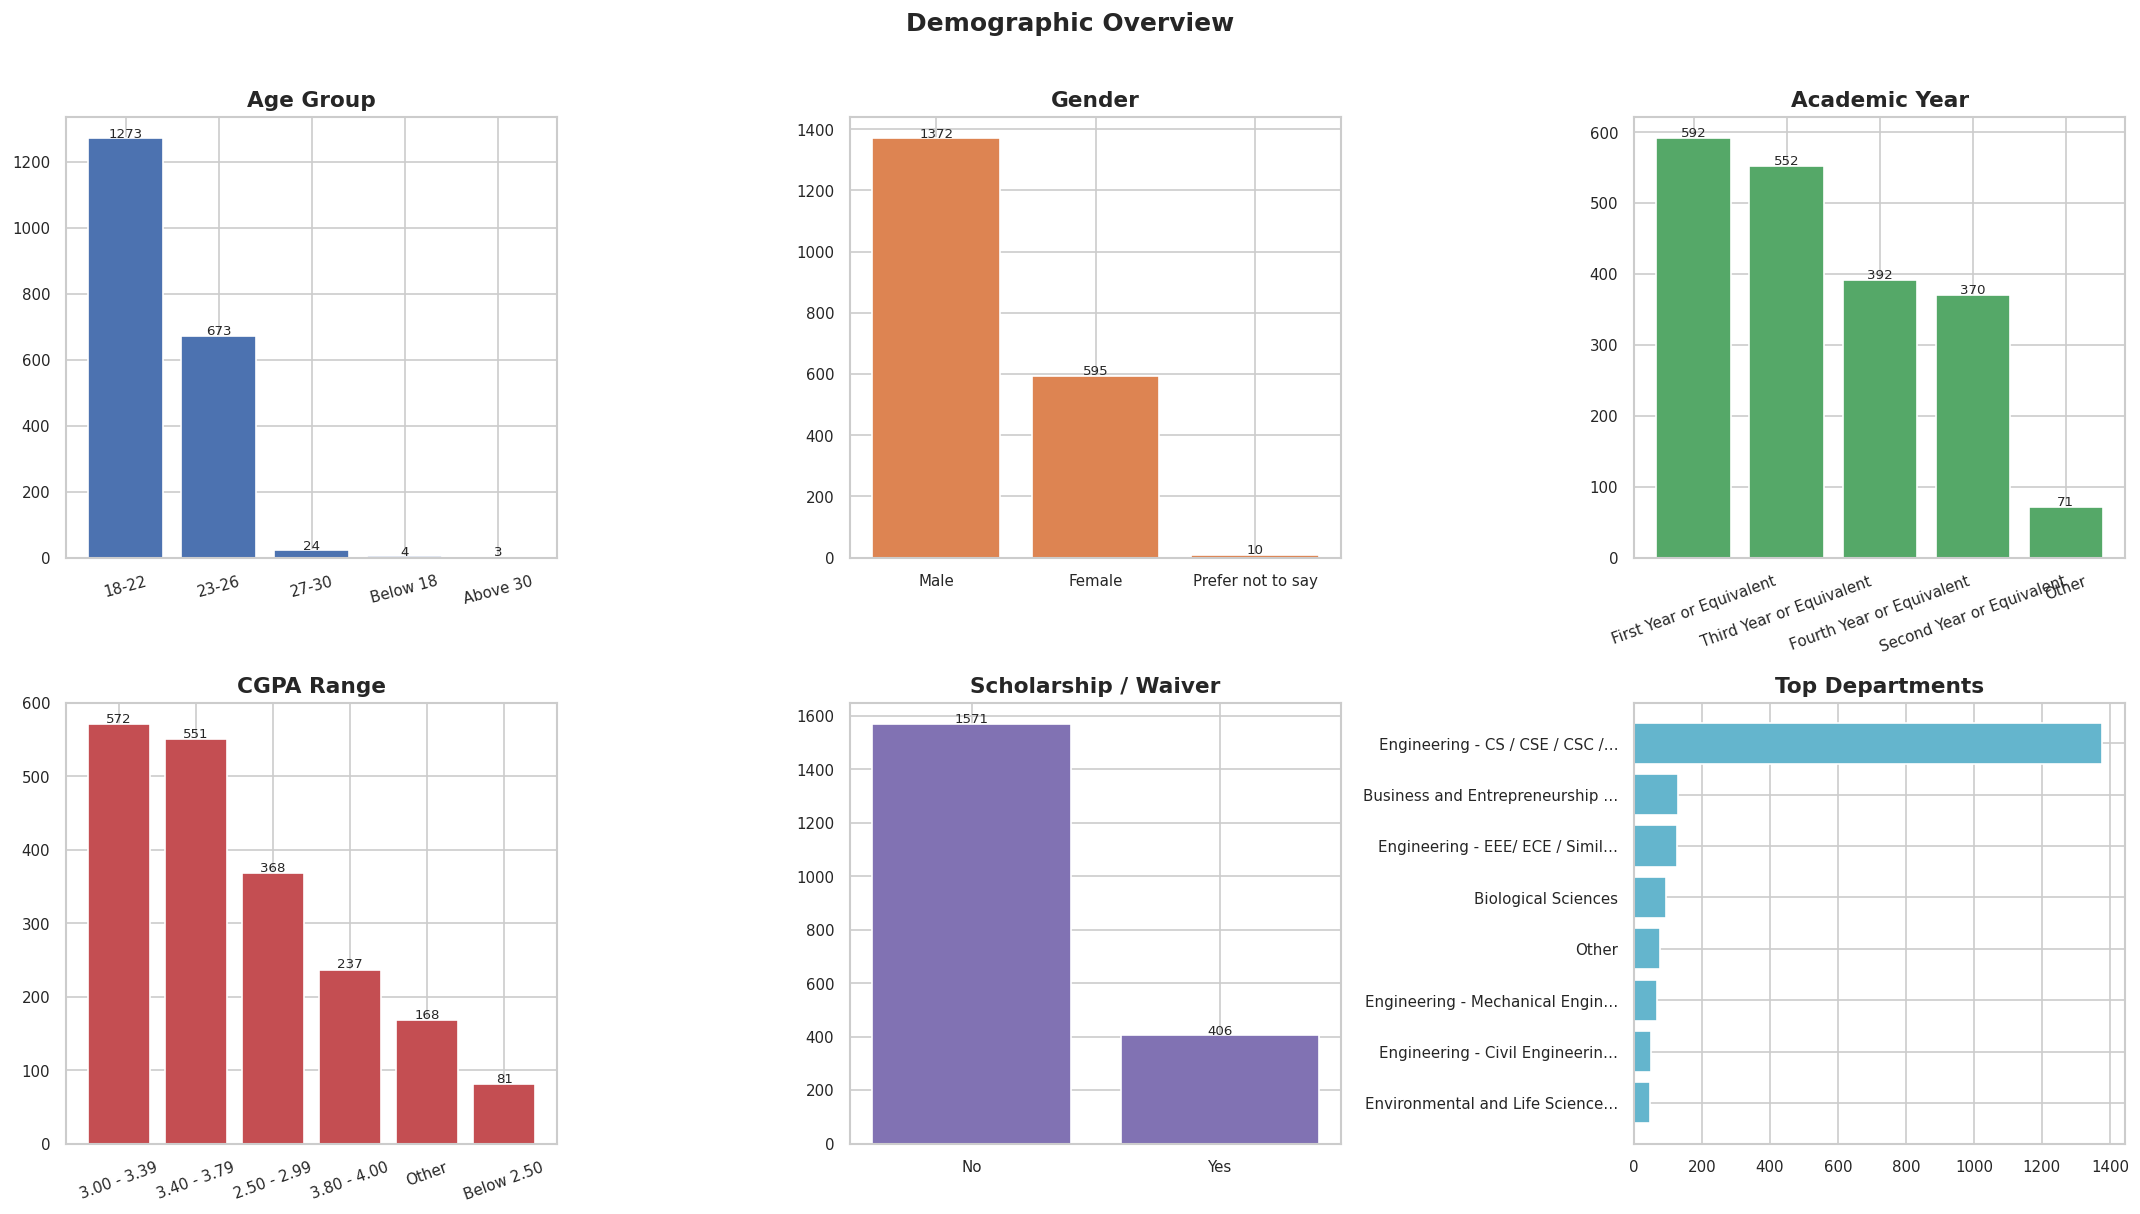

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

def bar_plot(col, ax, title, color, rotation=0):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=rotation)
    for i, v in enumerate(vc.values):
        ax.text(i, v + 2, str(v), ha='center', fontsize=8)

bar_plot('Age',           axes[0,0], 'Age Group',         '#4C72B0', rotation=15)
bar_plot('Gender',        axes[0,1], 'Gender',            '#DD8452')
bar_plot('Academic_Year', axes[0,2], 'Academic Year',     '#55A868', rotation=20)
bar_plot('CGPA',          axes[1,0], 'CGPA Range',        '#C44E52', rotation=20)
bar_plot('Scholarship',   axes[1,1], 'Scholarship / Waiver', '#8172B3')

# Department (truncated labels)
dept_vc = df['Department'].value_counts().head(8)
short_labels = [d[:30] + '…' if len(d) > 30 else d for d in dept_vc.index]
axes[1,2].barh(short_labels[::-1], dept_vc.values[::-1], color='#64B5CD', edgecolor='white')
axes[1,2].set_title('Top Departments', fontweight='bold')

plt.suptitle('Demographic Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Score Distributions - Anxiety, Stress, Depression

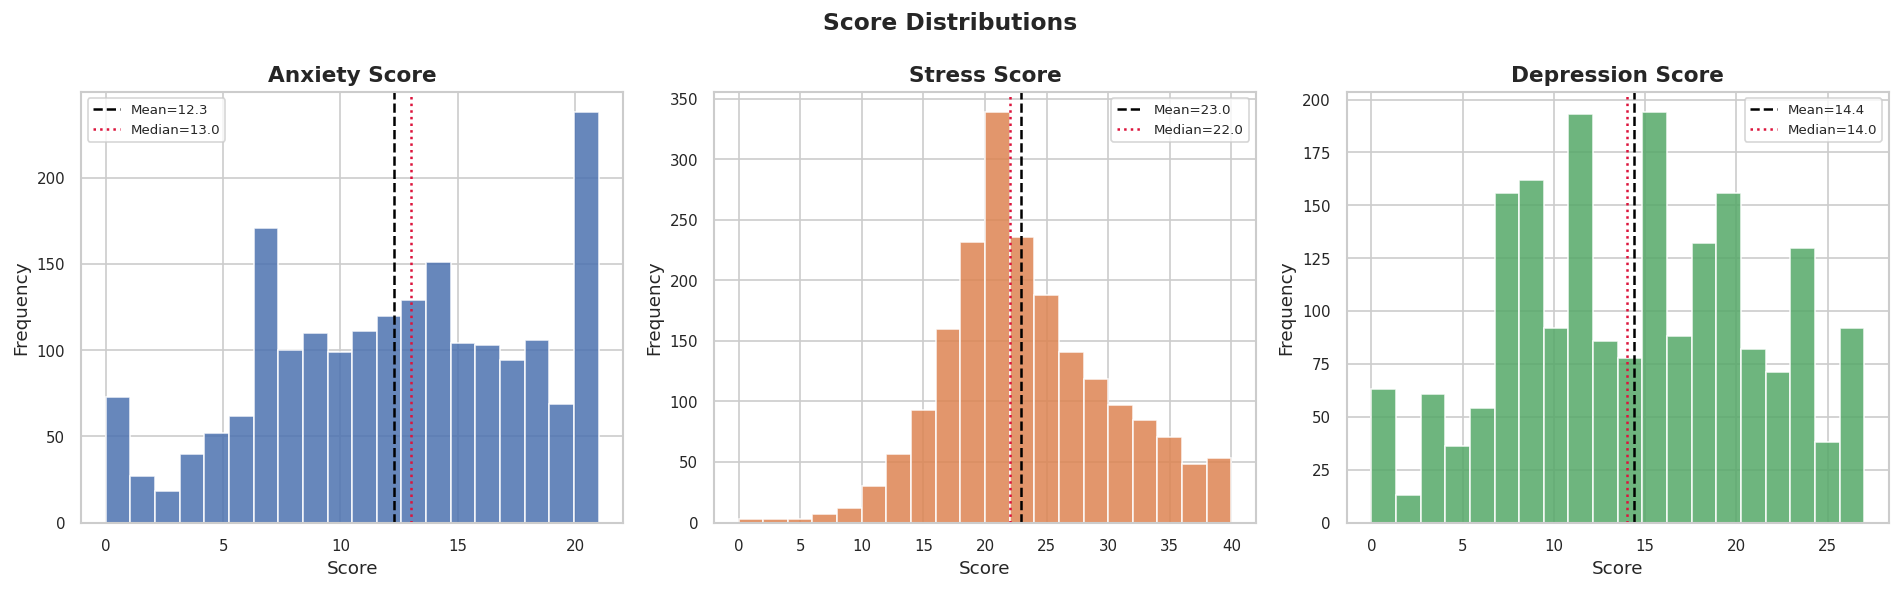


Descriptive Statistics:


,Anxiety_Score,Stress_Score,Depression_Score
count,1977.00,1977.00,1977.00
mean,12.29,22.96,14.37
std,5.50,6.75,6.66
min,0.00,0.00,0.00
25%,8.00,19.00,9.00
50%,13.00,22.00,14.00
75%,17.00,27.00,19.00
max,21.00,40.00,27.00


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

score_info = [
    ('Anxiety_Score',    'Anxiety Score',    PALETTE['anxiety']),
    ('Stress_Score',     'Stress Score',     PALETTE['stress']),
    ('Depression_Score', 'Depression Score', PALETTE['depression']),
]

for ax, (col, title, color) in zip(axes, score_info):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='black',  linestyle='--', linewidth=1.5, label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='crimson', linestyle=':',  linewidth=1.5, label=f'Median={df[col].median():.1f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('Score Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nDescriptive Statistics:')
df[['Anxiety_Score', 'Stress_Score', 'Depression_Score']].describe().round(2)

## 8. All Three Label Distributions

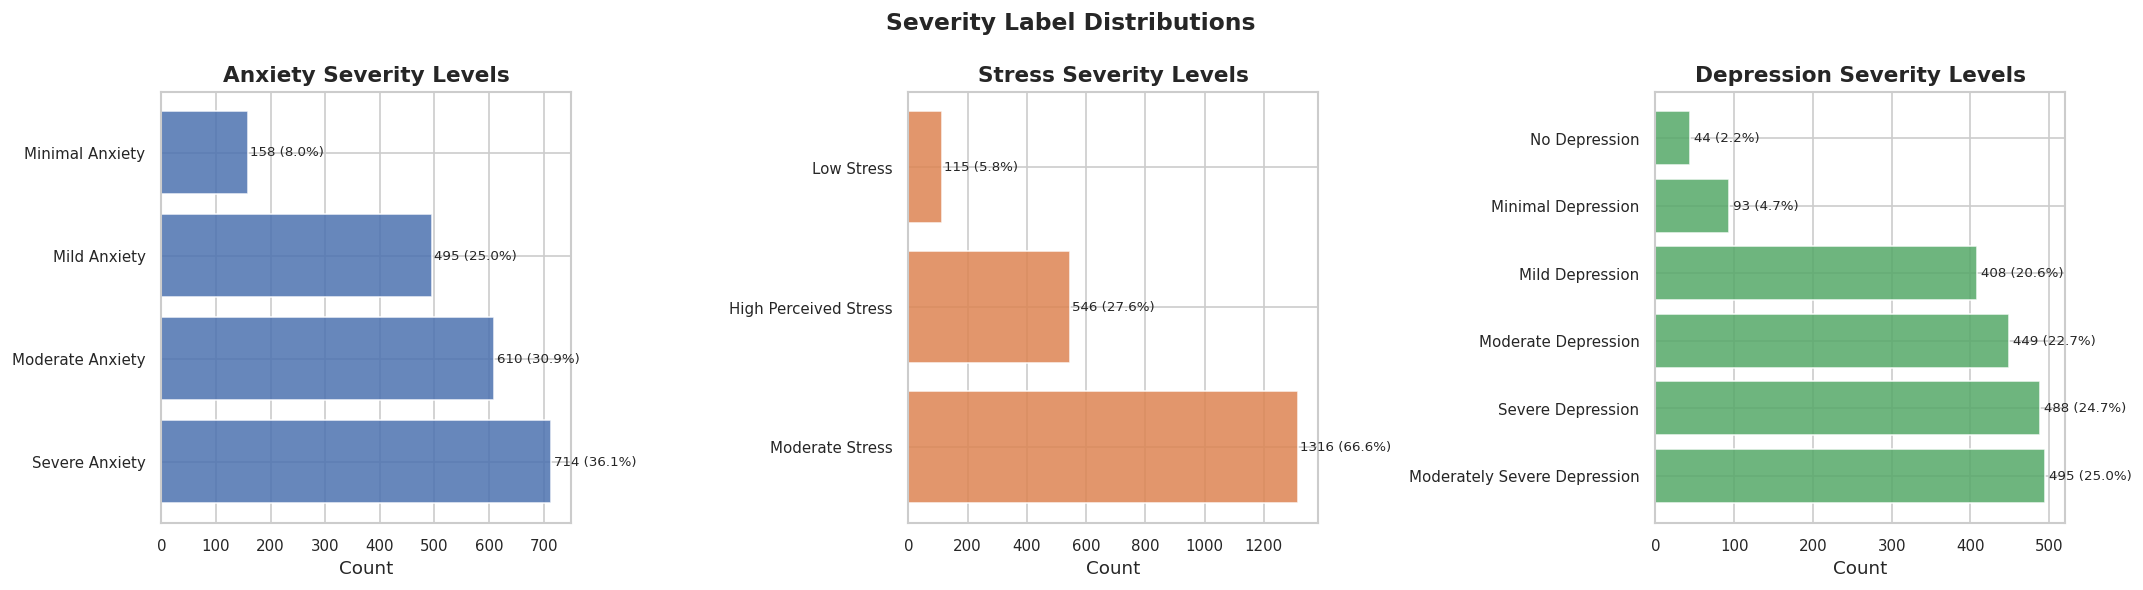

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

label_groups = [
    ('Anxiety_Label',    'Anxiety Severity Levels',    PALETTE['anxiety']),
    ('Stress_Label',     'Stress Severity Levels',     PALETTE['stress']),
    ('Depression_Label', 'Depression Severity Levels', PALETTE['depression']),
]

for ax, (col, title, color) in zip(axes, label_groups):
    vc = df[col].value_counts()
    bars = ax.barh(vc.index, vc.values, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Count')
    for bar, val in zip(bars, vc.values):
        ax.text(val + 5, bar.get_y() + bar.get_height()/2,
                f'{val} ({val/len(df)*100:.1f}%)', va='center', fontsize=8)

plt.suptitle('Severity Label Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Correlation Analysis

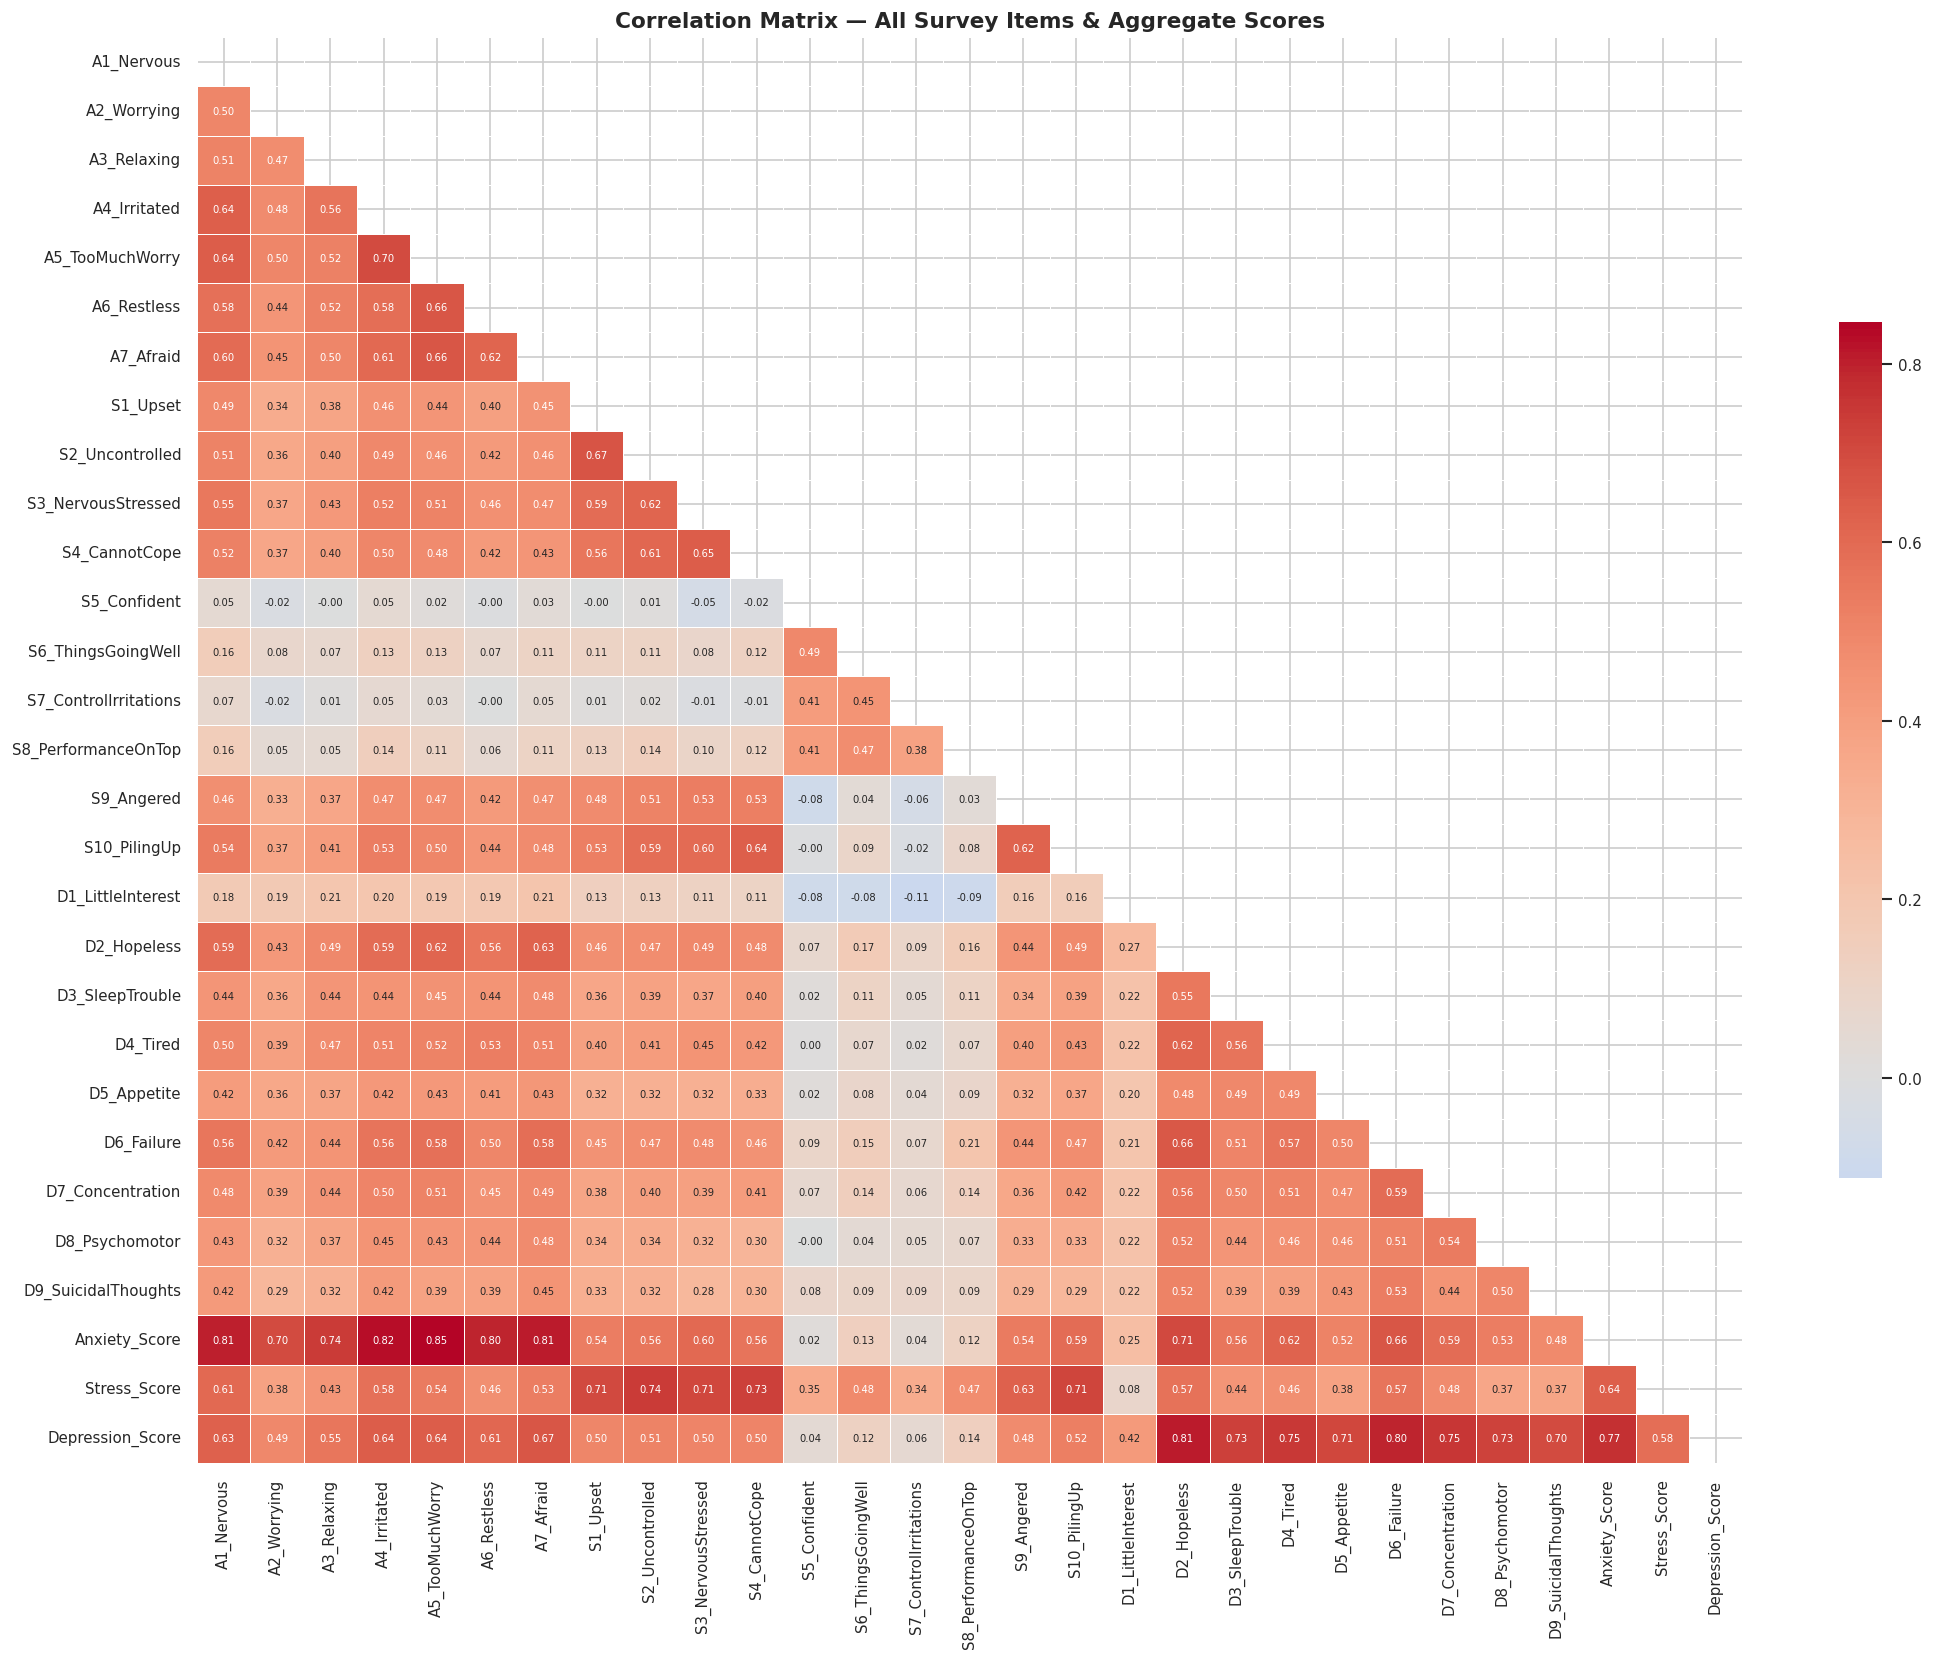

In [12]:
# All numeric item columns
anxiety_items    = [c for c in df.columns if c.startswith('A') and '_' in c and c[1].isdigit()]
stress_items     = [c for c in df.columns if c.startswith('S') and '_' in c and c[1].isdigit()]
depression_items = [c for c in df.columns if c.startswith('D') and '_' in c and c[1].isdigit()]
all_items        = anxiety_items + stress_items + depression_items + ['Anxiety_Score', 'Stress_Score', 'Depression_Score']

corr_matrix = df[all_items].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 6},
            cbar_kws={'shrink': 0.6})
ax.set_title('Correlation Matrix — All Survey Items & Aggregate Scores', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

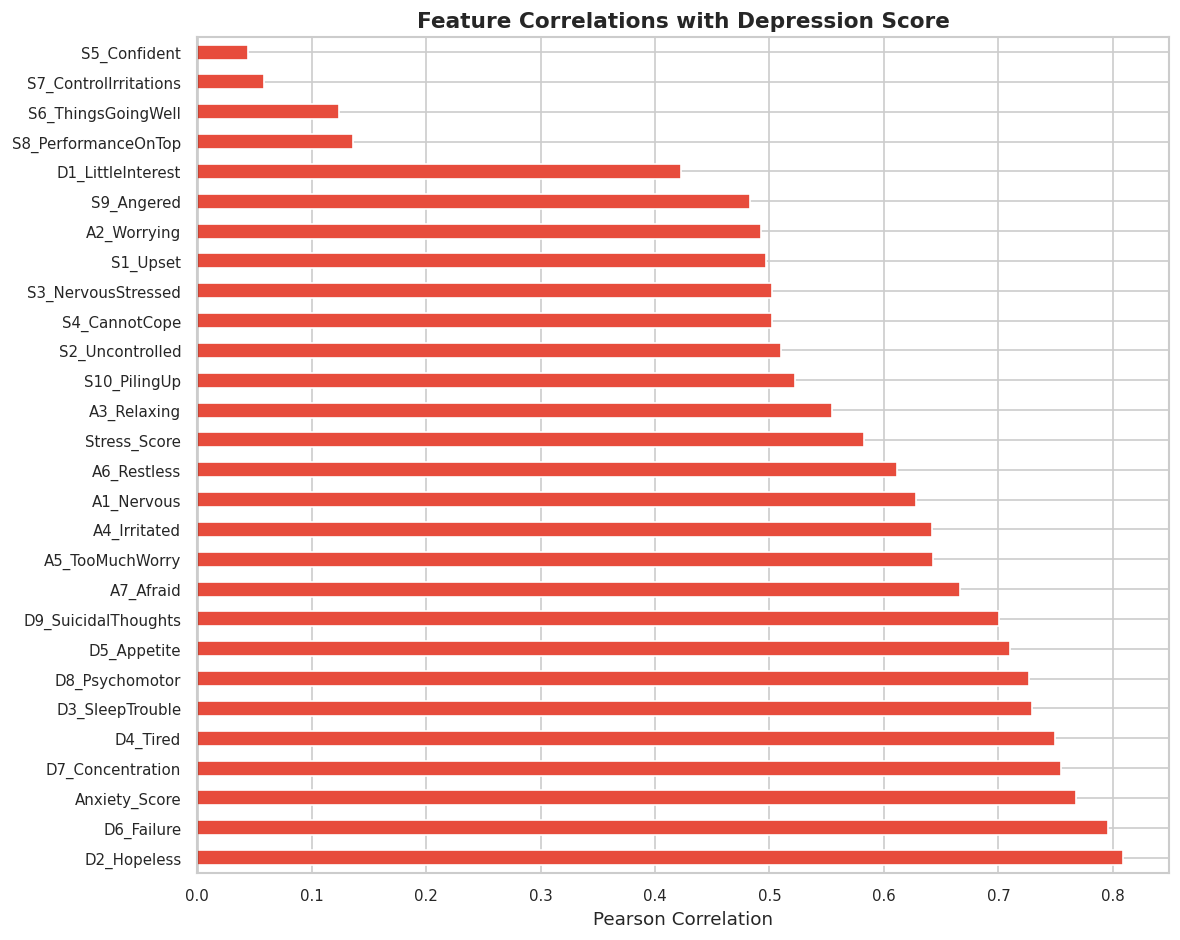

Top 5 positive correlates with Depression:
D2_Hopeless         0.808371
D6_Failure          0.795671
Anxiety_Score       0.767879
D7_Concentration    0.754918
D4_Tired            0.749280
Name: Depression_Score, dtype: float64

Top 5 negative correlates with Depression:
D1_LittleInterest        0.422632
S8_PerformanceOnTop      0.135820
S6_ThingsGoingWell       0.124319
S7_ControlIrritations    0.058580
S5_Confident             0.044150
Name: Depression_Score, dtype: float64


In [13]:
# Top correlations with Depression Score
dep_corr = df[all_items].corr()['Depression_Score'].drop('Depression_Score').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in dep_corr]
dep_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Correlations with Depression Score', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Top 5 positive correlates with Depression:')
print(dep_corr.head(5))
print('\nTop 5 negative correlates with Depression:')
print(dep_corr.tail(5))

## 10. Scores by Demographics

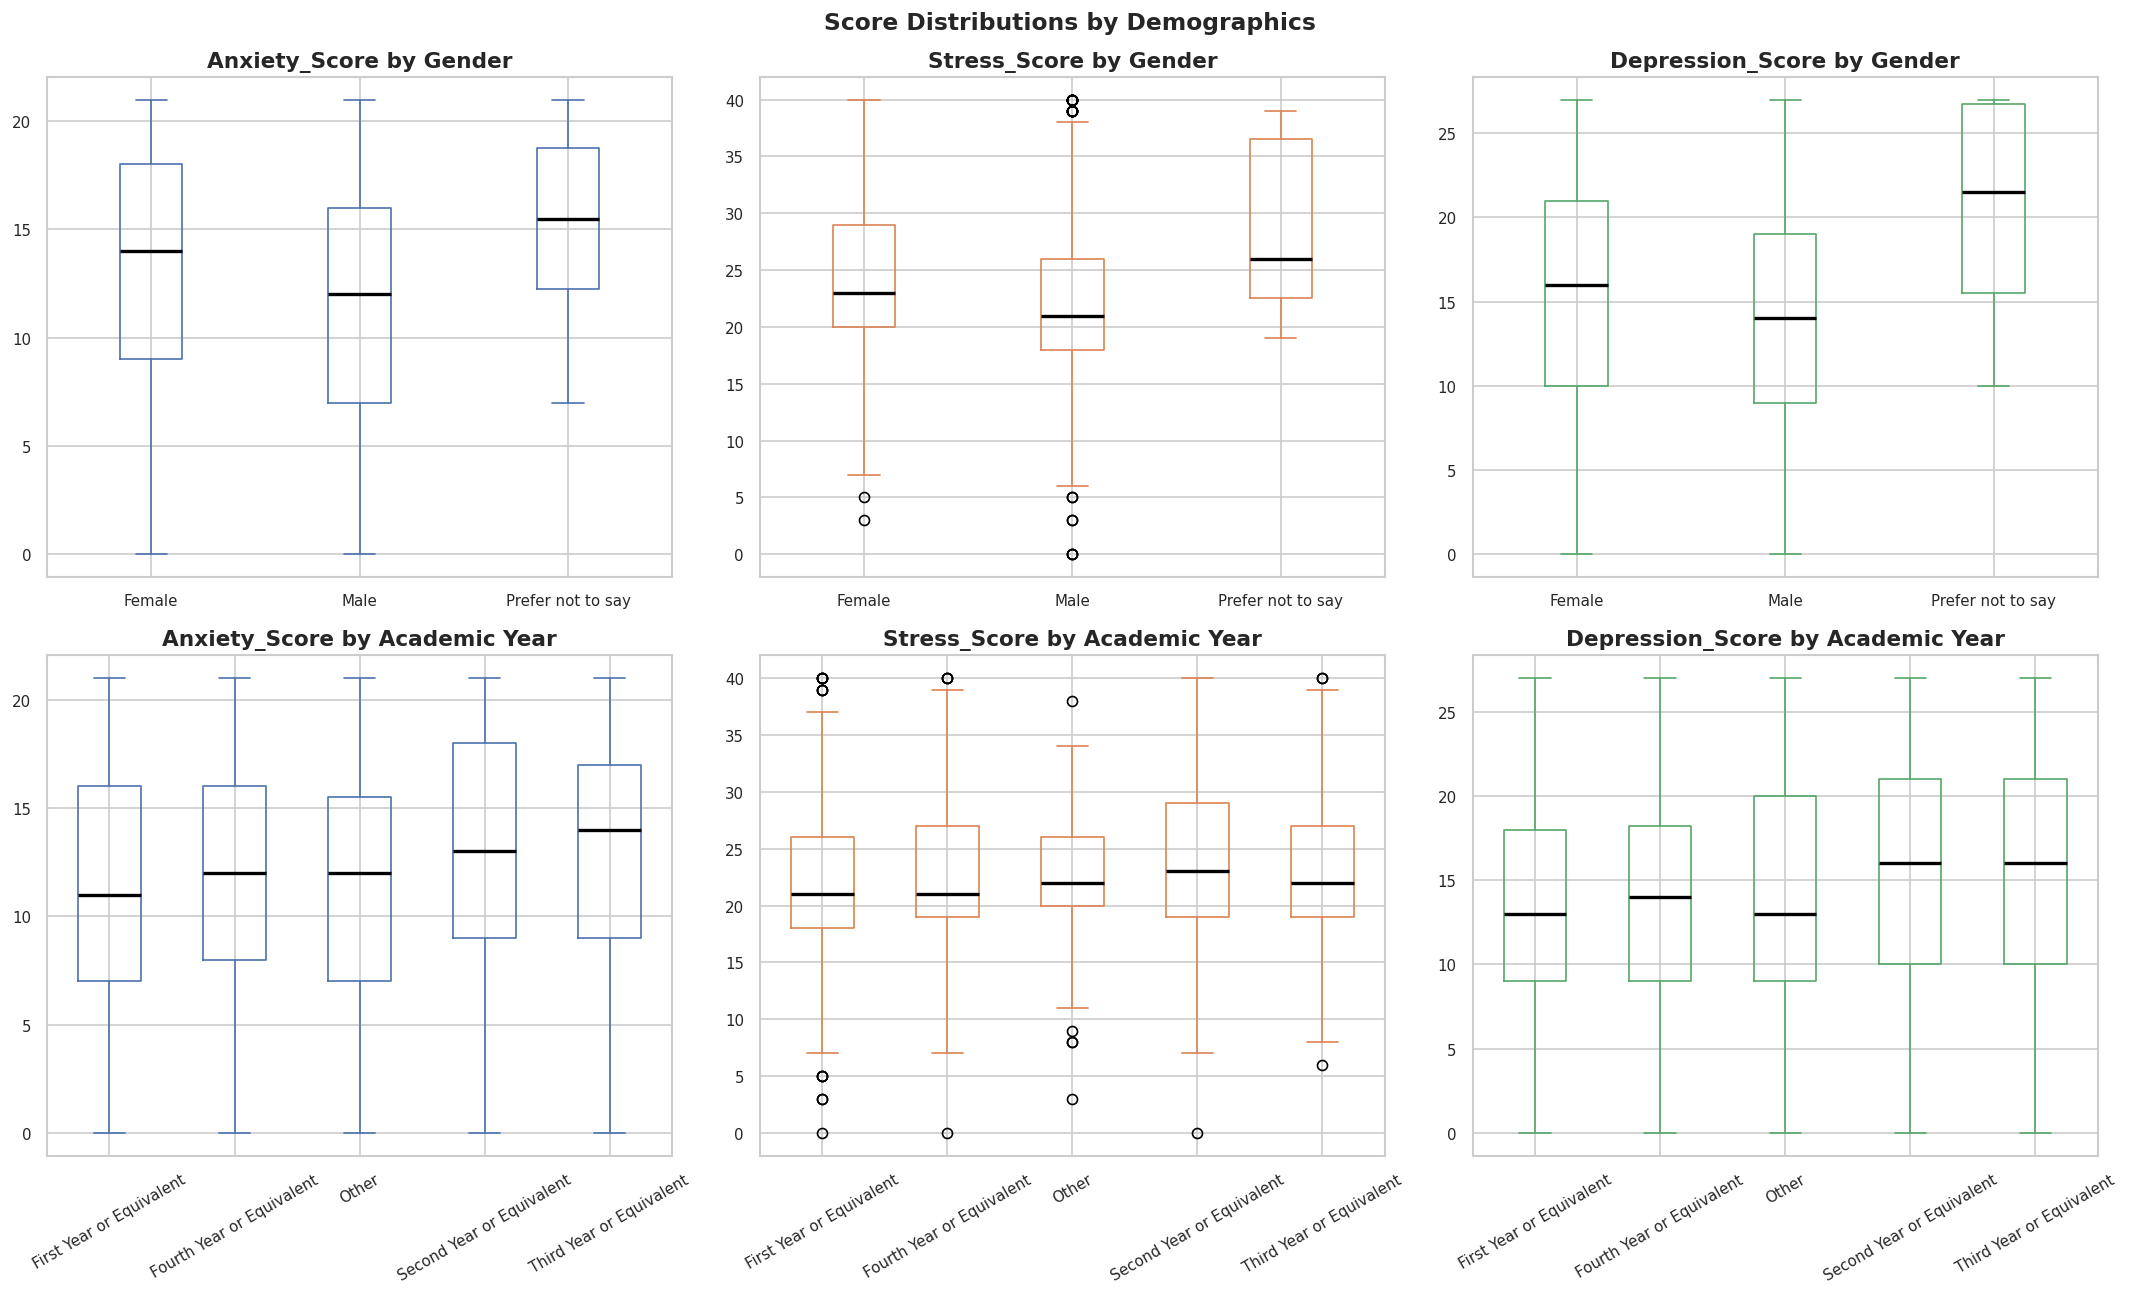

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
scores = ['Anxiety_Score', 'Stress_Score', 'Depression_Score']
score_colors = [PALETTE['anxiety'], PALETTE['stress'], PALETTE['depression']]

for col_idx, (score, color) in enumerate(zip(scores, score_colors)):
    # By Gender
    df.boxplot(column=score, by='Gender', ax=axes[0, col_idx],
               boxprops=dict(color=color), medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(color=color), capprops=dict(color=color))
    axes[0, col_idx].set_title(f'{score} by Gender', fontweight='bold')
    axes[0, col_idx].set_xlabel('')

    # By Academic Year
    df.boxplot(column=score, by='Academic_Year', ax=axes[1, col_idx],
               boxprops=dict(color=color), medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(color=color), capprops=dict(color=color))
    axes[1, col_idx].set_title(f'{score} by Academic Year', fontweight='bold')
    axes[1, col_idx].tick_params(axis='x', rotation=30)
    axes[1, col_idx].set_xlabel('')

plt.suptitle('')  # remove default suptitle from boxplot
fig.suptitle('Score Distributions by Demographics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

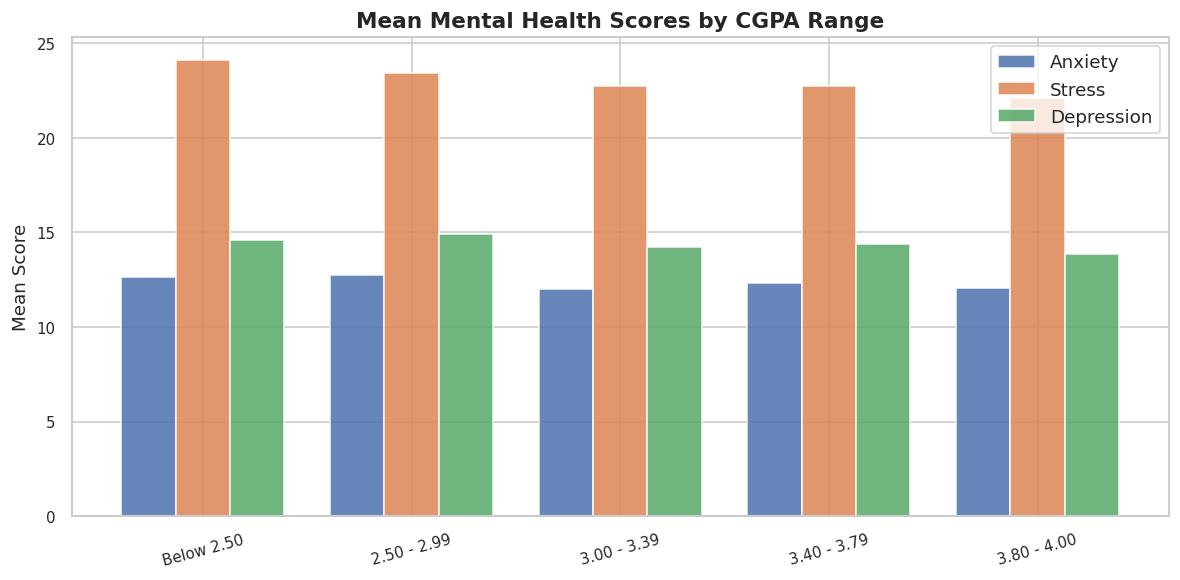

In [15]:
# Mean scores by CGPA
cgpa_order = ['Below 2.50', '2.50 - 2.99', '3.00 - 3.39', '3.40 - 3.79', '3.80 - 4.00']
existing_cgpa = [g for g in cgpa_order if g in df['CGPA'].unique()]

cgpa_means = df.groupby('CGPA')[scores].mean().reindex(existing_cgpa).dropna()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cgpa_means))
width = 0.26
for i, (score, color) in enumerate(zip(scores, score_colors)):
    ax.bar(x + i * width, cgpa_means[score], width, label=score.replace('_Score', ''), color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(cgpa_means.index, rotation=15)
ax.set_title('Mean Mental Health Scores by CGPA Range', fontweight='bold')
ax.set_ylabel('Mean Score')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Pairplot - Scores Colored by Depression Label

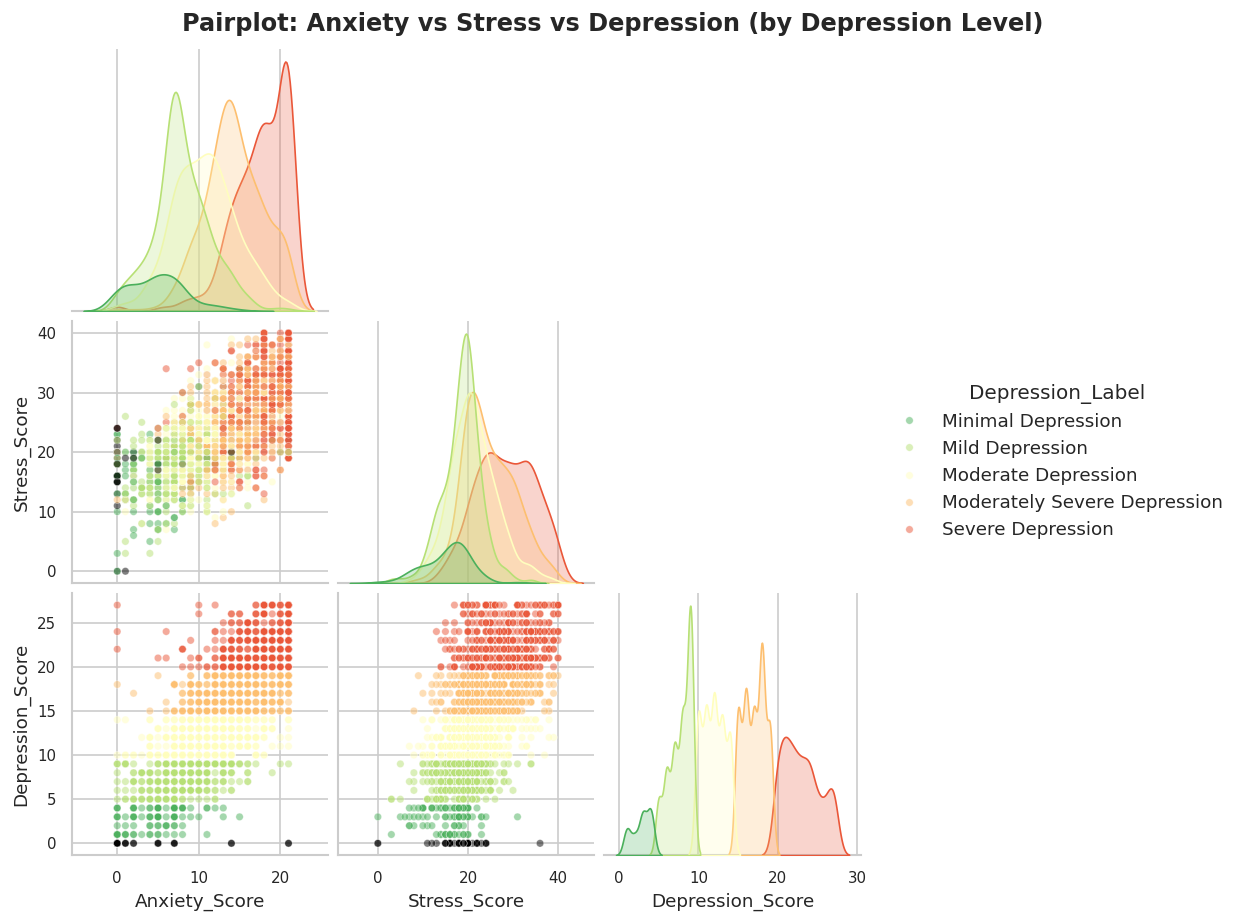

In [16]:
plot_df = df[['Anxiety_Score', 'Stress_Score', 'Depression_Score', 'Depression_Label']].copy()

g = sns.pairplot(
    plot_df,
    hue='Depression_Label',
    hue_order=existing_labels,
    palette='RdYlGn_r',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20},
    corner=True,
)
g.fig.suptitle('Pairplot: Anxiety vs Stress vs Depression (by Depression Level)',
               y=1.02, fontweight='bold')
plt.show()

## 12. Individual Survey Item Analysis

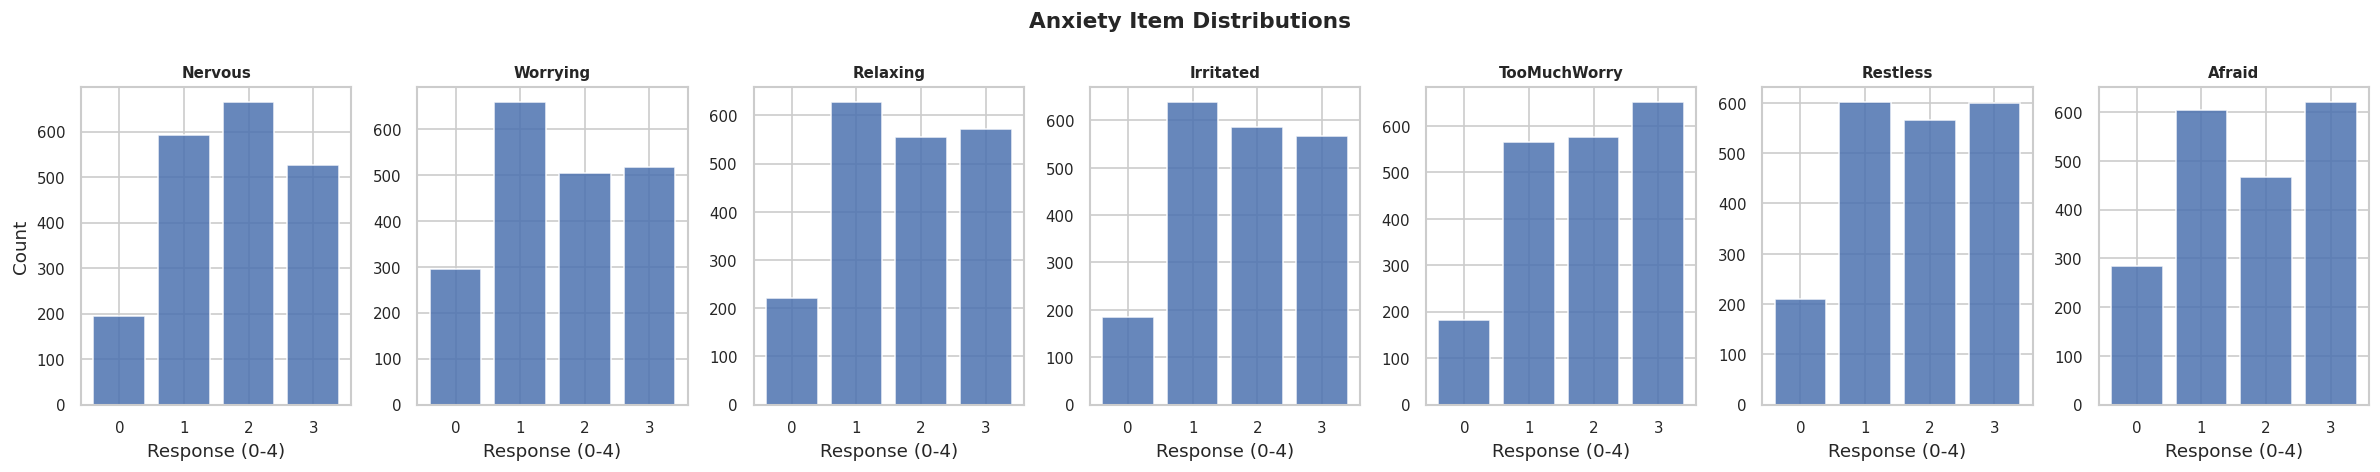

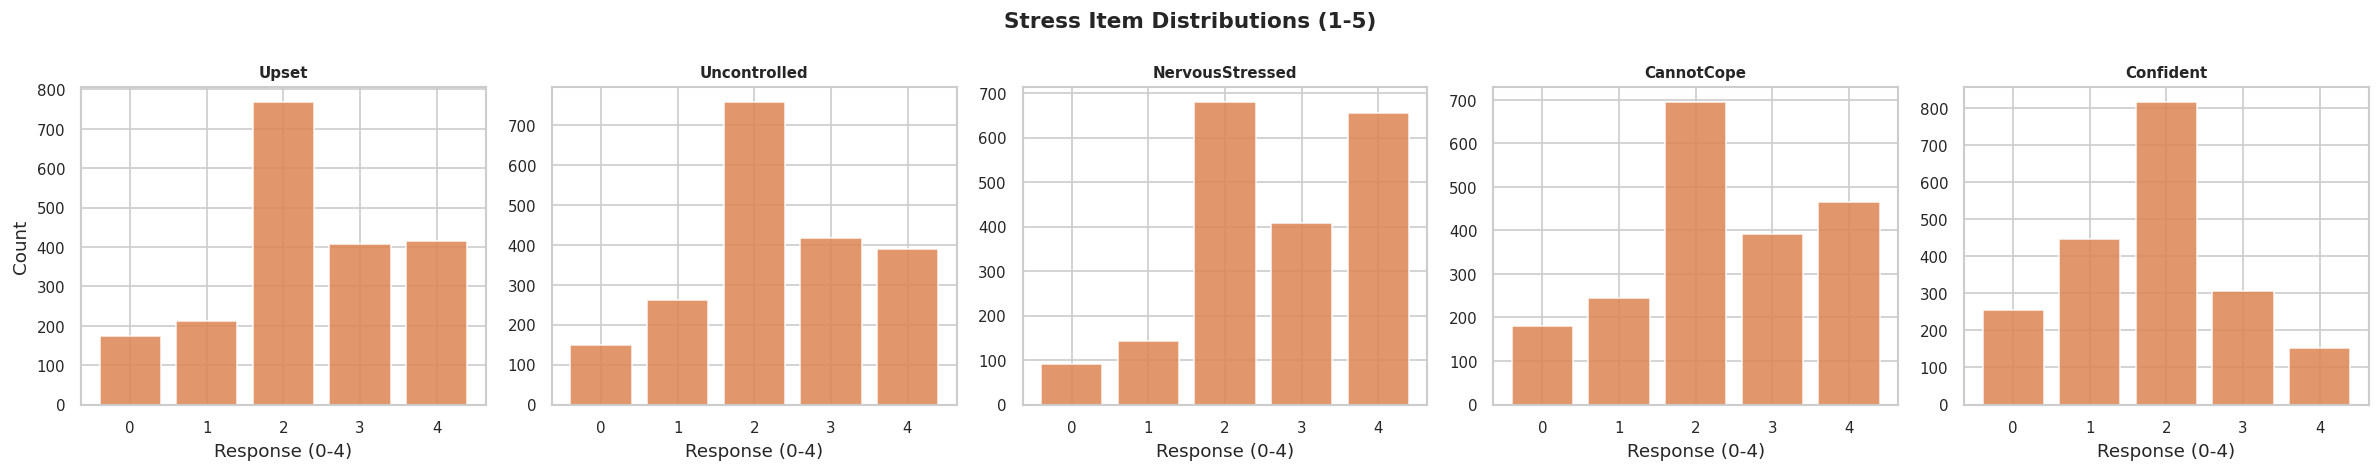

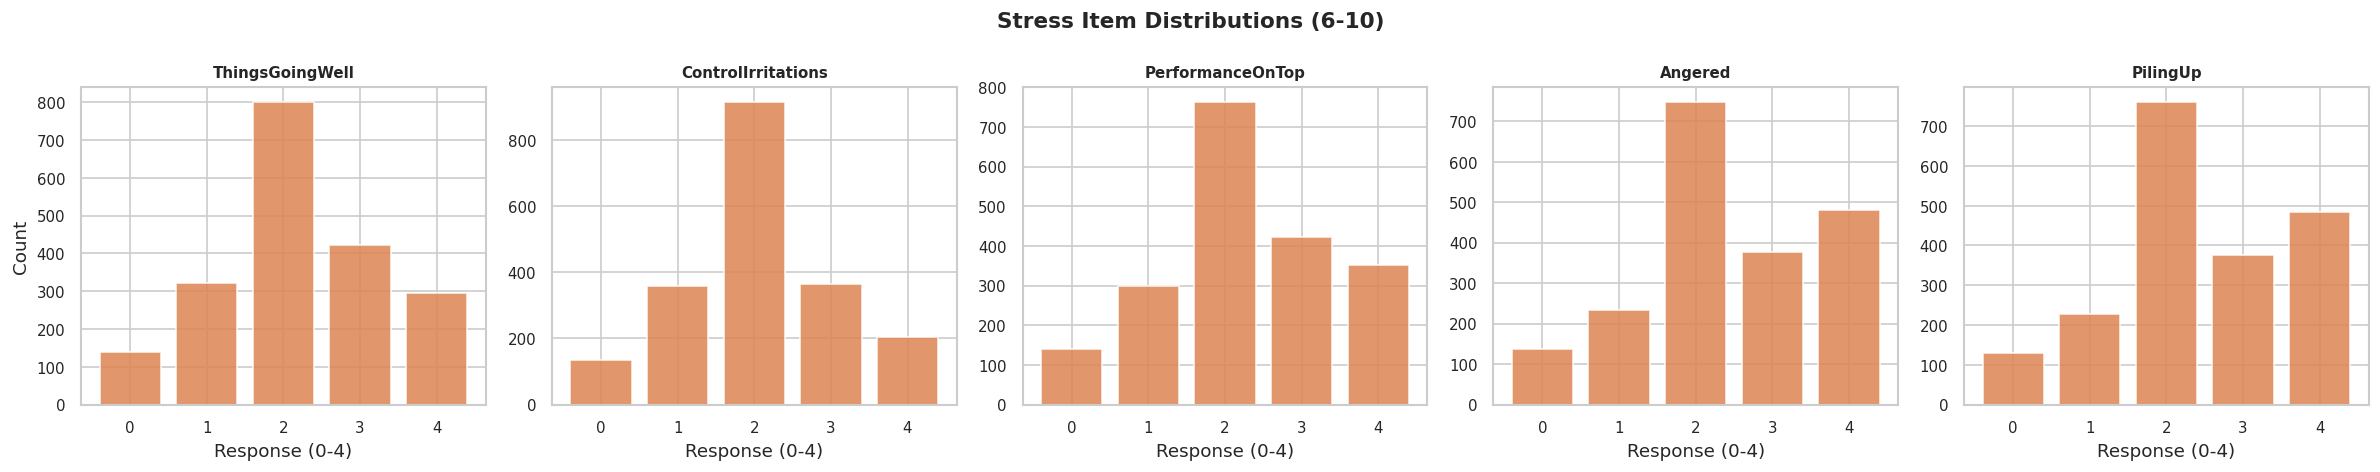

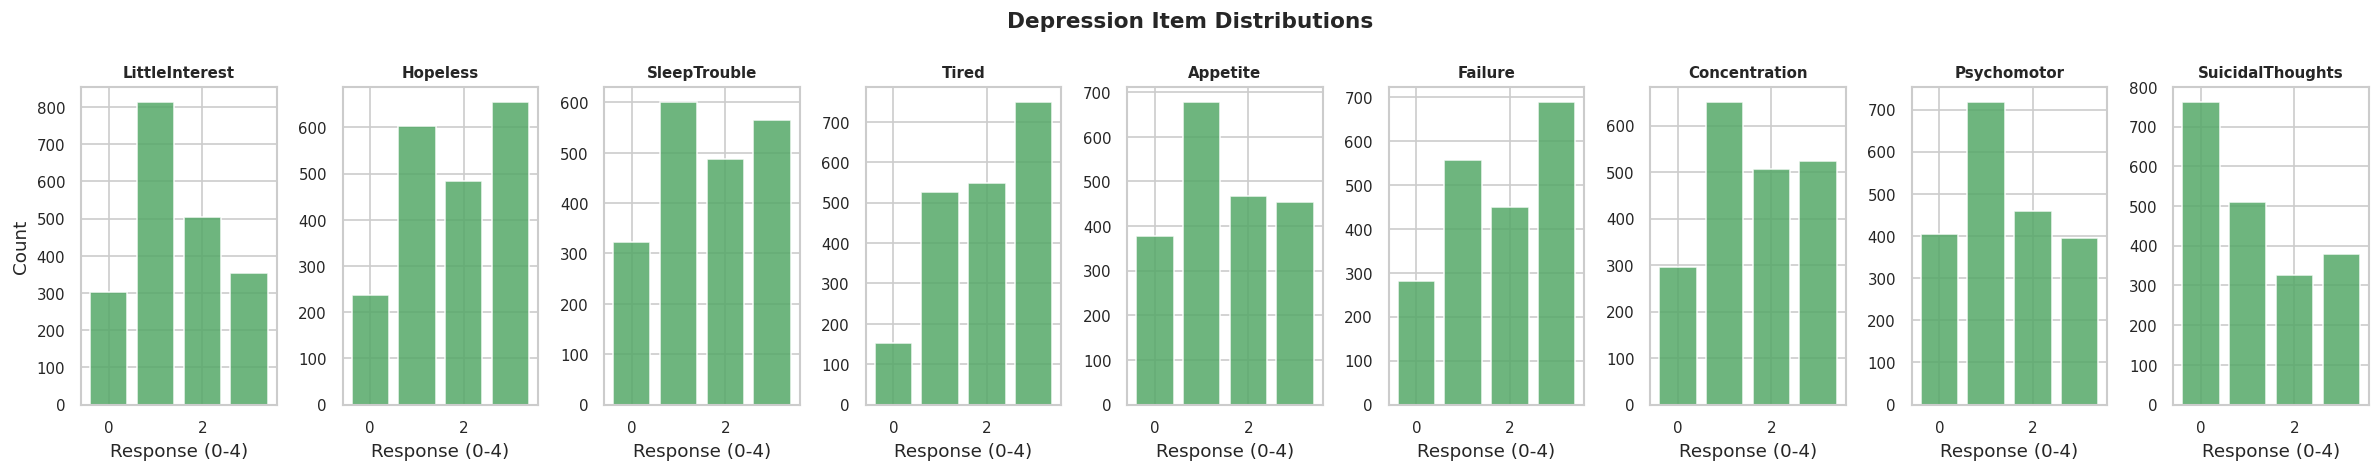

In [17]:
def item_distribution_plot(items, title, color, figsize=(16, 5)):
    fig, axes = plt.subplots(1, len(items), figsize=figsize)
    for ax, col in zip(axes, items):
        vc = df[col].value_counts().sort_index()
        ax.bar(vc.index, vc.values, color=color, edgecolor='white', alpha=0.85)
        ax.set_title(col.split('_', 1)[-1], fontsize=9, fontweight='bold')
        ax.set_xlabel('Response (0-4)')
        ax.set_ylabel('Count' if ax == axes[0] else '')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    return fig

fig1 = item_distribution_plot(anxiety_items,    'Anxiety Item Distributions',    PALETTE['anxiety'],    (20, 4))
plt.show()

fig2 = item_distribution_plot(stress_items[:5], 'Stress Item Distributions (1-5)', PALETTE['stress'],  (20, 4))
plt.show()

fig3 = item_distribution_plot(stress_items[5:], 'Stress Item Distributions (6-10)', PALETTE['stress'], (20, 4))
plt.show()

fig4 = item_distribution_plot(depression_items, 'Depression Item Distributions', PALETTE['depression'], (20, 4))
plt.show()

## 13. Violin Plots - Score Distribution by Gender

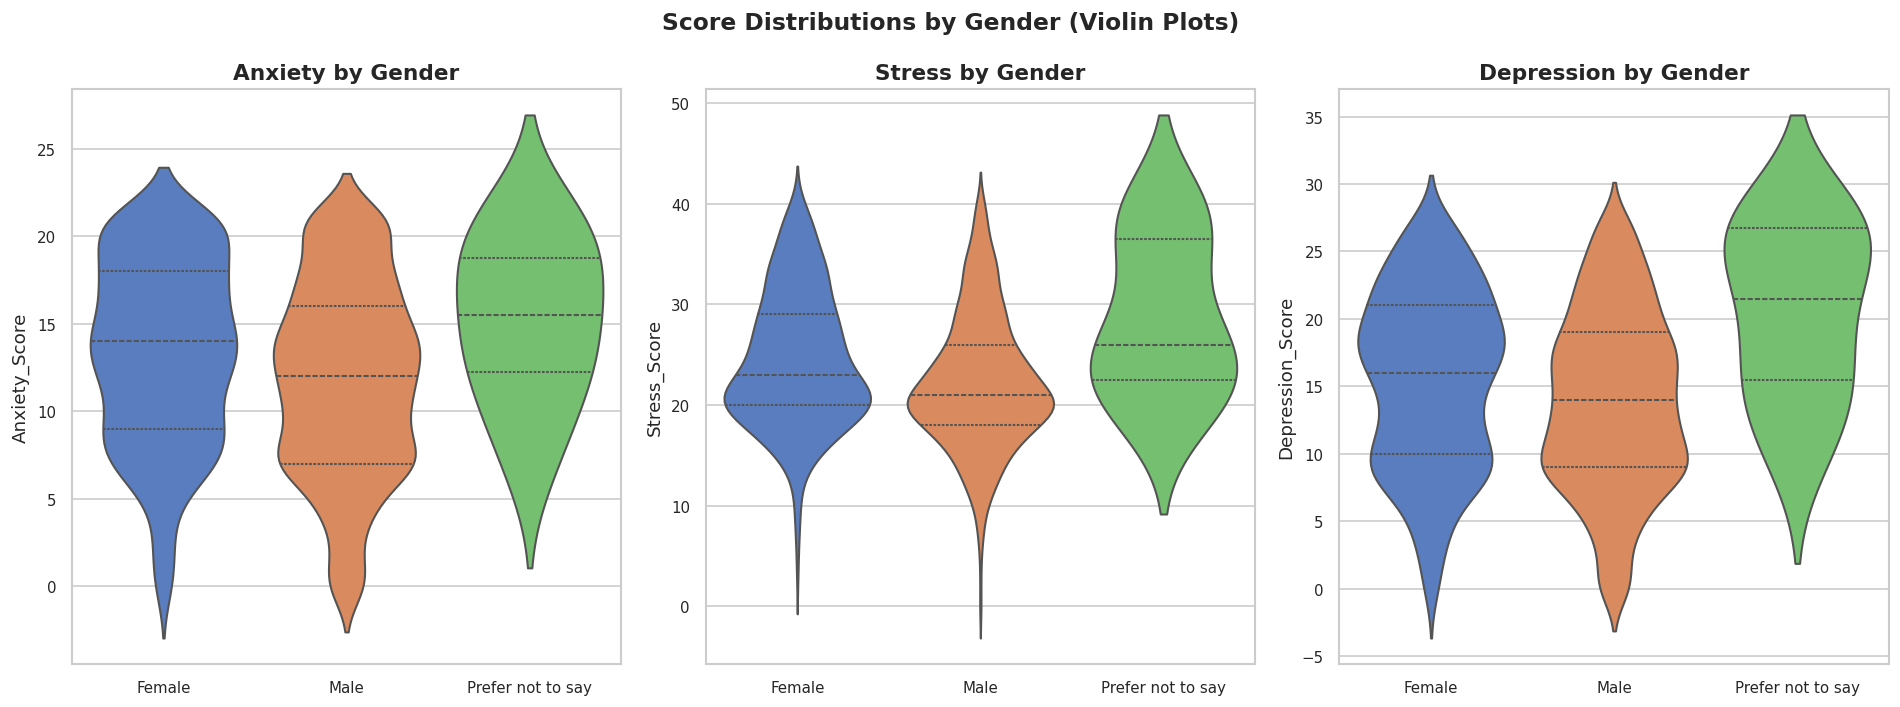

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, (score, color) in zip(axes, zip(scores, score_colors)):
    sns.violinplot(data=df, x='Gender', y=score, ax=ax, palette='muted', inner='quartile')
    ax.set_title(f'{score.replace("_Score", "")} by Gender', fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Score Distributions by Gender (Violin Plots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Risk Label Mapping (for Model Training)
> We'll map the 5 depression levels to **3 risk classes**: Low, Moderate, High

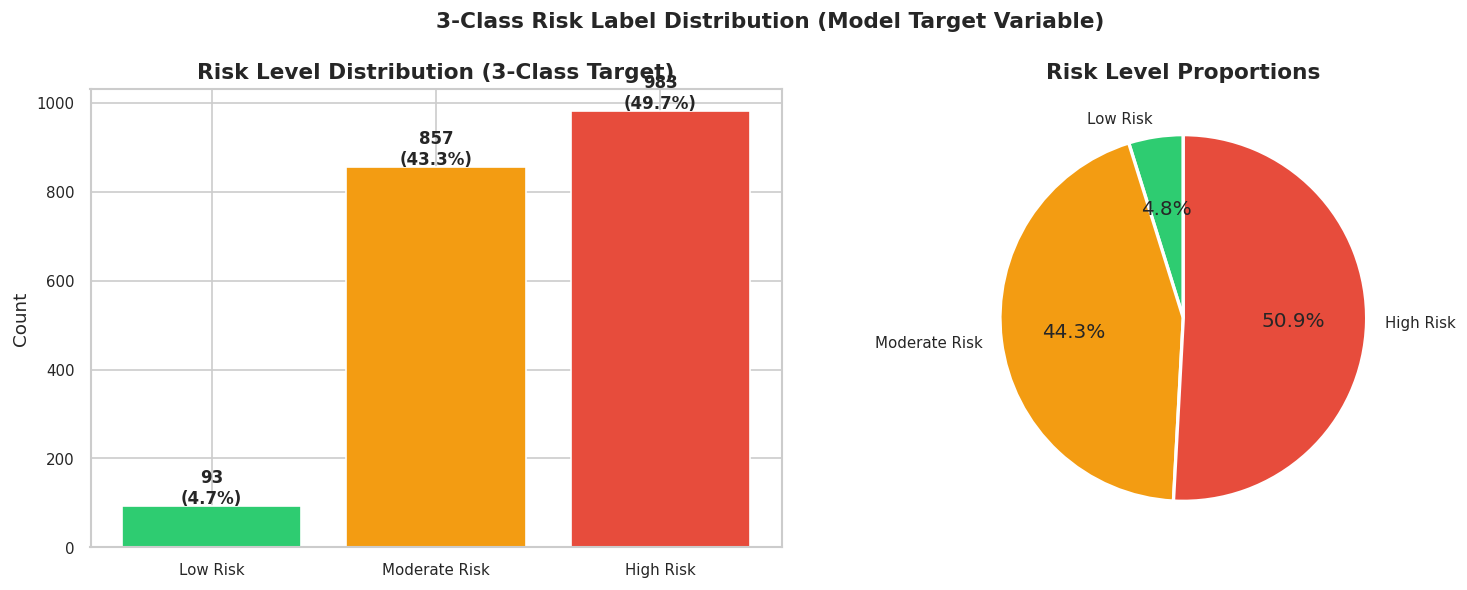

               Count  Percentage
Risk_Level                      
Low Risk          93         4.7
Moderate Risk    857        43.3
High Risk        983        49.7


In [19]:
risk_map = {
    'Minimal Depression':           'Low Risk',
    'Mild Depression':              'Moderate Risk',
    'Moderate Depression':          'Moderate Risk',
    'Moderately Severe Depression': 'High Risk',
    'Severe Depression':            'High Risk',
}

df['Risk_Level'] = df['Depression_Label'].map(risk_map)

risk_counts = df['Risk_Level'].value_counts()
risk_order  = ['Low Risk', 'Moderate Risk', 'High Risk']
risk_counts = risk_counts.reindex(risk_order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(risk_counts.index, risk_counts.values,
            color=PALETTE['risk'], edgecolor='white', linewidth=1)
axes[0].set_title('Risk Level Distribution (3-Class Target)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')

axes[1].pie(risk_counts.values, labels=risk_counts.index,
            autopct='%1.1f%%', colors=PALETTE['risk'],
            wedgeprops=dict(edgecolor='white', linewidth=2),
            startangle=90)
axes[1].set_title('Risk Level Proportions', fontweight='bold')

plt.suptitle('3-Class Risk Label Distribution (Model Target Variable)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(pd.DataFrame({'Count': risk_counts, 'Percentage': (risk_counts/len(df)*100).round(1)}))

## 15. Scores vs Risk Level

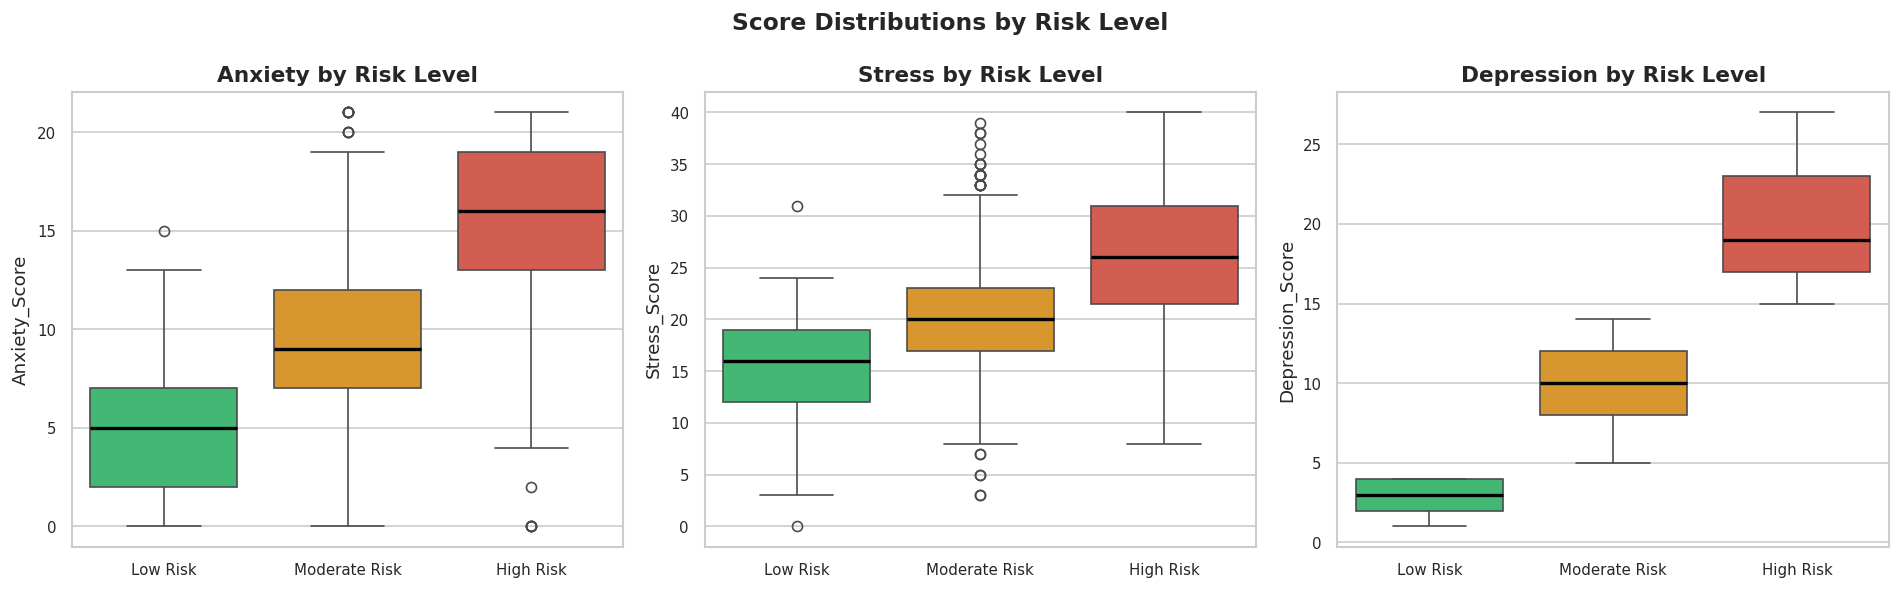

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (score, color) in zip(axes, zip(scores, score_colors)):
    sns.boxplot(data=df, x='Risk_Level', y=score, order=risk_order,
                palette=PALETTE['risk'], ax=ax,
                medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'{score.replace("_Score", "")} by Risk Level', fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Score Distributions by Risk Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 16. Scholarship / Waiver vs Risk Level

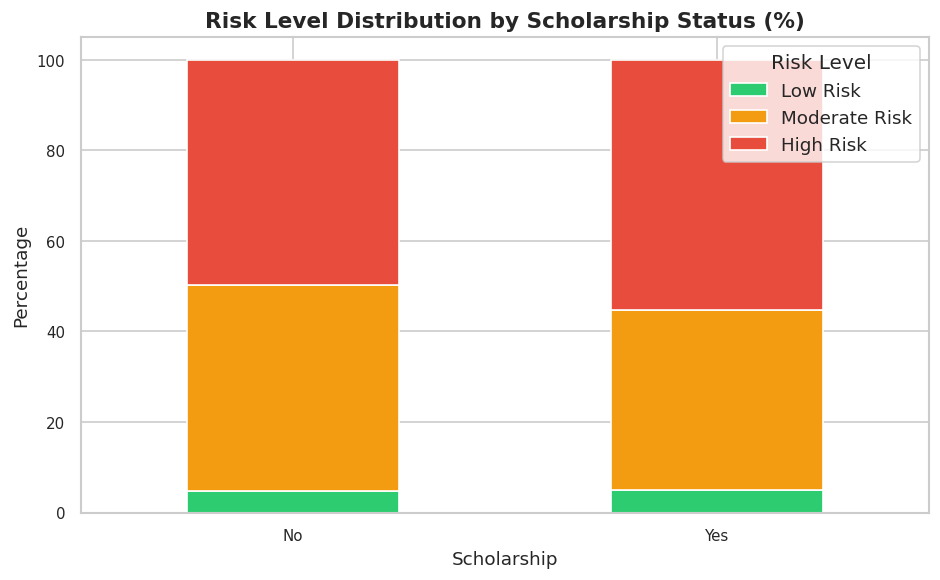

Risk_Level   Low Risk  Moderate Risk  High Risk
Scholarship                                    
No                4.8           45.5       49.7
Yes               5.0           39.8       55.2


In [21]:
scholarship_risk = df.groupby(['Scholarship', 'Risk_Level']).size().unstack(fill_value=0)
scholarship_risk = scholarship_risk.reindex(columns=risk_order, fill_value=0)

scholarship_risk_pct = scholarship_risk.div(scholarship_risk.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5))
scholarship_risk_pct.plot(kind='bar', stacked=True, ax=ax,
                           color=PALETTE['risk'], edgecolor='white')
ax.set_title('Risk Level Distribution by Scholarship Status (%)', fontweight='bold')
ax.set_xlabel('Scholarship')
ax.set_ylabel('Percentage')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Risk Level', loc='upper right')
plt.tight_layout()
plt.show()

print(scholarship_risk_pct.round(1))

## 17. Item-Level Mean Scores by Risk Level (Heatmap)

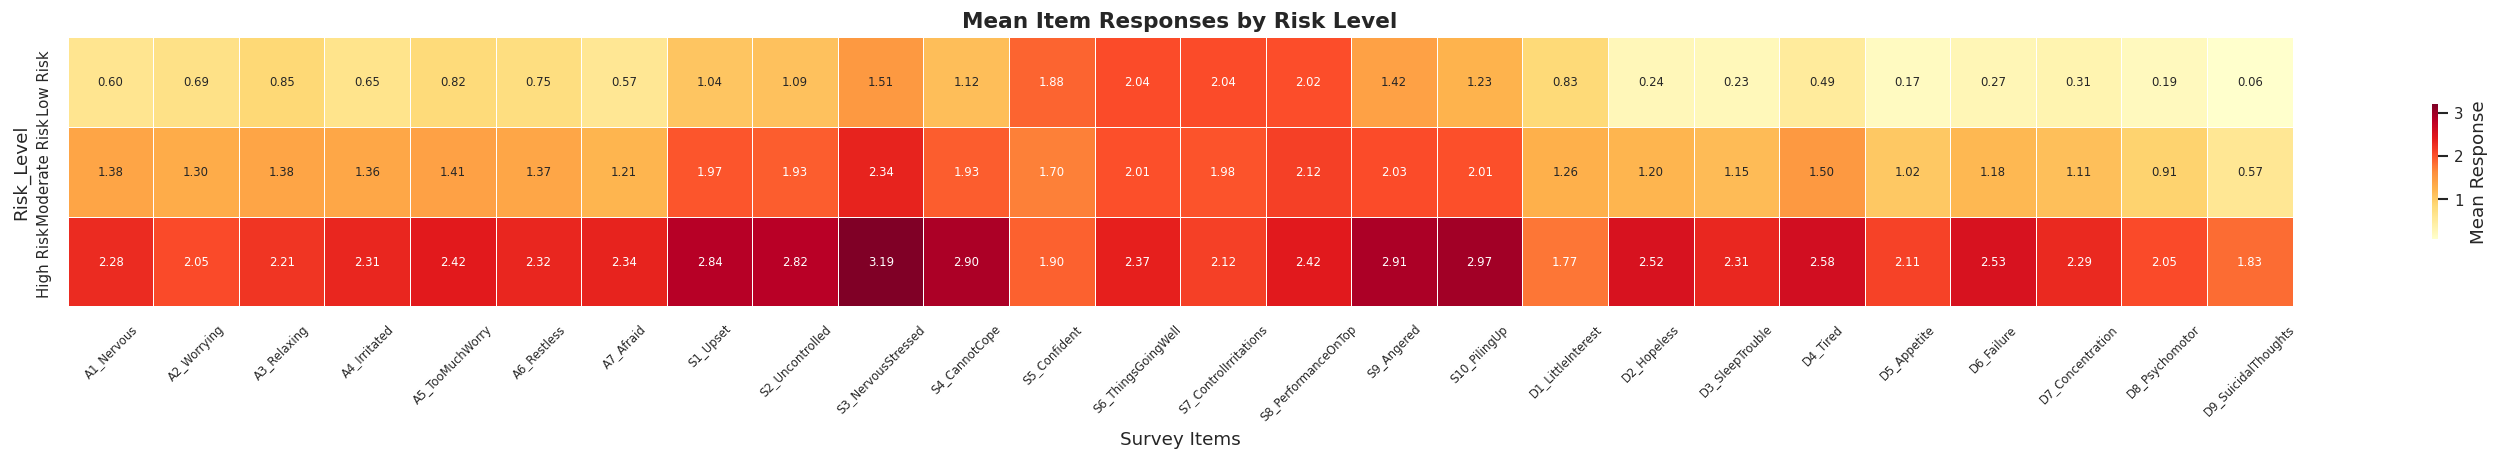

In [22]:
all_question_items = anxiety_items + stress_items + depression_items
risk_item_means = df.groupby('Risk_Level')[all_question_items].mean().reindex(risk_order)

fig, ax = plt.subplots(figsize=(24, 4))
sns.heatmap(risk_item_means, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, annot_kws={'size': 7},
            cbar_kws={'label': 'Mean Response', 'shrink': 0.5})
ax.set_title('Mean Item Responses by Risk Level', fontweight='bold', fontsize=13)
ax.set_xlabel('Survey Items')
ax.tick_params(axis='x', rotation=45, labelsize=7)
plt.tight_layout()
plt.show()

## 18. Suicidal Ideation Item (D9) - Critical Flag

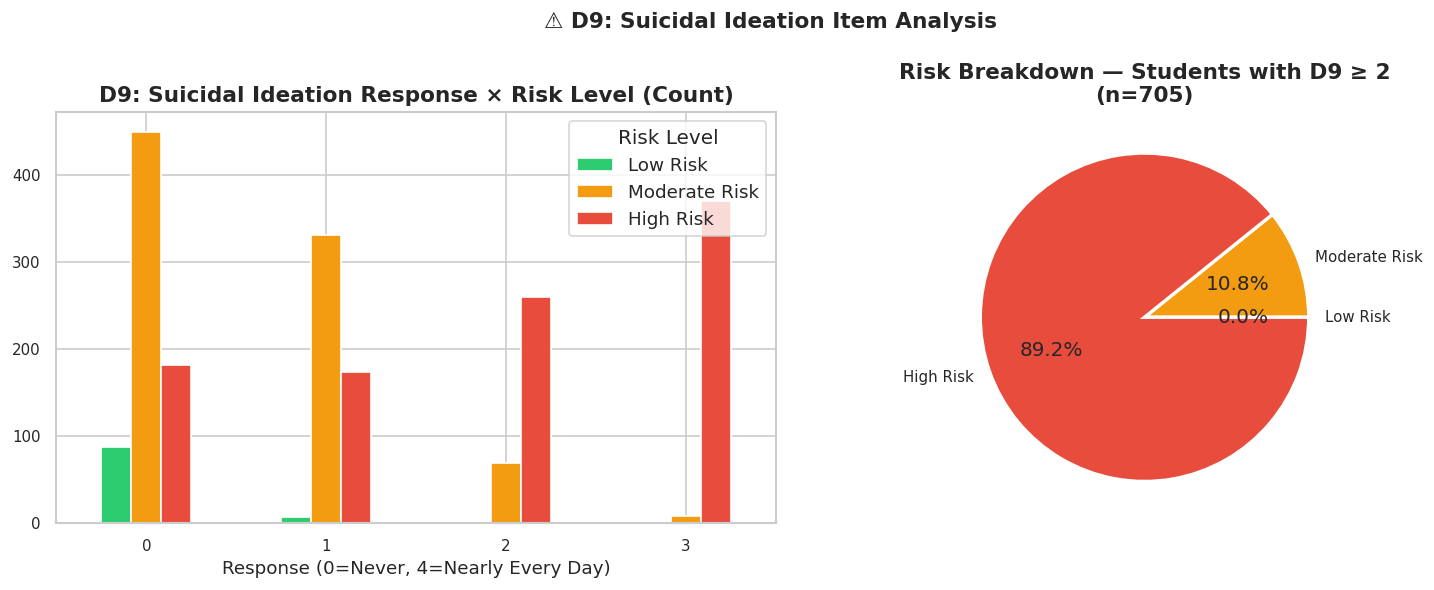

Students with D9 ≥ 2 (concerning): 705 (35.7%)


In [23]:
d9_risk = df.groupby(['D9_SuicidalThoughts', 'Risk_Level']).size().unstack(fill_value=0)
d9_risk = d9_risk.reindex(columns=risk_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count
d9_risk.plot(kind='bar', stacked=False, ax=axes[0], color=PALETTE['risk'], edgecolor='white')
axes[0].set_title('D9: Suicidal Ideation Response × Risk Level (Count)', fontweight='bold')
axes[0].set_xlabel('Response (0=Never, 4=Nearly Every Day)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Risk Level')

# % of those with D9>=2
high_d9 = df[df['D9_SuicidalThoughts'] >= 2]
high_d9_risk = high_d9['Risk_Level'].value_counts().reindex(risk_order, fill_value=0)
axes[1].pie(high_d9_risk, labels=high_d9_risk.index, autopct='%1.1f%%',
            colors=PALETTE['risk'], wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title(f'Risk Breakdown — Students with D9 ≥ 2\n(n={len(high_d9)})', fontweight='bold')

plt.suptitle('⚠️ D9: Suicidal Ideation Item Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pct_high_d9 = len(high_d9) / len(df) * 100
print(f'Students with D9 ≥ 2 (concerning): {len(high_d9)} ({pct_high_d9:.1f}%)')

## 19. Key Insights & Summary

In [24]:
print('=' * 65)
print('EDA KEY INSIGHTS — STUDENT MENTAL HEALTH DATASET')
print('=' * 65)

print(f'''
📊 DATASET
  • Total records        : {len(df):,}
  • Total features       : {df.shape[1]}
  • Missing values       : None
  • Duplicate rows       : {df.duplicated().sum()}

🧍 DEMOGRAPHICS
  • Gender split         : {dict(df['Gender'].value_counts())}
  • Most common age      : {df['Age'].value_counts().index[0]}
  • Most common year     : {df['Academic_Year'].value_counts().index[0]}

📈 SCORE STATISTICS
  • Anxiety  Score  mean : {df['Anxiety_Score'].mean():.2f}  (σ={df['Anxiety_Score'].std():.2f})
  • Stress   Score  mean : {df['Stress_Score'].mean():.2f}  (σ={df['Stress_Score'].std():.2f})
  • Depression Score mean: {df['Depression_Score'].mean():.2f}  (σ={df['Depression_Score'].std():.2f})

🏷️  3-CLASS RISK DISTRIBUTION
''')

for level in risk_order:
    n   = risk_counts.get(level, 0)
    pct = n / len(df) * 100
    print(f'  {level:<16}: {n:5,} ({pct:.1f}%)')

print(f'''
⚠️  CLASS IMBALANCE NOTE
  {'✅ Relatively balanced' if risk_counts.min() / risk_counts.max() > 0.5
   else '⚠️ Imbalanced — use class_weight or SMOTE during training'}

🔗 TOP CORRELATES WITH DEPRESSION SCORE
  Positive: {', '.join(dep_corr.head(3).index.tolist())}
  Negative: {', '.join(dep_corr.tail(3).index.tolist())}

⚠️  SUICIDAL IDEATION (D9 ≥ 2)
  Flagged students: {len(high_d9):,} ({pct_high_d9:.1f}%) — requires attention

🔧 FEATURE ENGINEERING RECOMMENDATIONS
  1. Use Anxiety + Stress + Depression TOTAL score as a composite feature
  2. Create binary flags for extreme responses (item score = 3 or 4)
  3. D9_SuicidalThoughts should be a high-priority sentinel feature
  4. CGPA and Academic Year encode differently - use ordinal encoding
  5. Address class imbalance using class_weight='balanced' in sklearn
  6. Consider dropping raw item columns after creating aggregate features
''')

EDA KEY INSIGHTS — STUDENT MENTAL HEALTH DATASET

📊 DATASET
  • Total records        : 1,977
  • Total features       : 40
  • Missing values       : None
  • Duplicate rows       : 3

🧍 DEMOGRAPHICS
  • Gender split         : {'Male': np.int64(1372), 'Female': np.int64(595), 'Prefer not to say': np.int64(10)}
  • Most common age      : 18-22
  • Most common year     : First Year or Equivalent

📈 SCORE STATISTICS
  • Anxiety  Score  mean : 12.29  (σ=5.50)
  • Stress   Score  mean : 22.96  (σ=6.75)
  • Depression Score mean: 14.37  (σ=6.66)

🏷️  3-CLASS RISK DISTRIBUTION

  Low Risk        :    93 (4.7%)
  Moderate Risk   :   857 (43.3%)
  High Risk       :   983 (49.7%)

⚠️  CLASS IMBALANCE NOTE
  ⚠️ Imbalanced — use class_weight or SMOTE during training

🔗 TOP CORRELATES WITH DEPRESSION SCORE
  Positive: D2_Hopeless, D6_Failure, Anxiety_Score
  Negative: S6_ThingsGoingWell, S7_ControlIrritations, S5_Confident

⚠️  SUICIDAL IDEATION (D9 ≥ 2)
  Flagged students: 705 (35.7%) — requires a

## 20. Save Cleaned & Labeled Dataset

In [25]:
df.to_csv('../dataset/cleaned_data_with_risk.csv', index=False)
print(f'✅ Cleaned dataset saved → cleaned_data_with_risk.csv')
print(f'   Shape: {df.shape}')
print(f'   Columns added: Risk_Level (3-class target)')
print(f'   Ready for Feature Engineering & Model Training!')

✅ Cleaned dataset saved → cleaned_data_with_risk.csv
   Shape: (1977, 40)
   Columns added: Risk_Level (3-class target)
   Ready for Feature Engineering & Model Training!
